<a href="https://colab.research.google.com/github/HimanshiKaravadra/CODSOFT/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
train = pd.read_csv(
    '/content/drive/MyDrive/fraudTrain.csv',
    nrows=100000
)

In [3]:
test = pd.read_csv(
    '/content/drive/MyDrive/fraudTest.csv',
    nrows=25000
)

In [4]:
print(train.shape)
print(test.shape)

(100000, 23)
(25000, 23)


In [5]:
train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
train.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [7]:
train['is_fraud'].value_counts()

,count
is_fraud,
0,99010
1,990


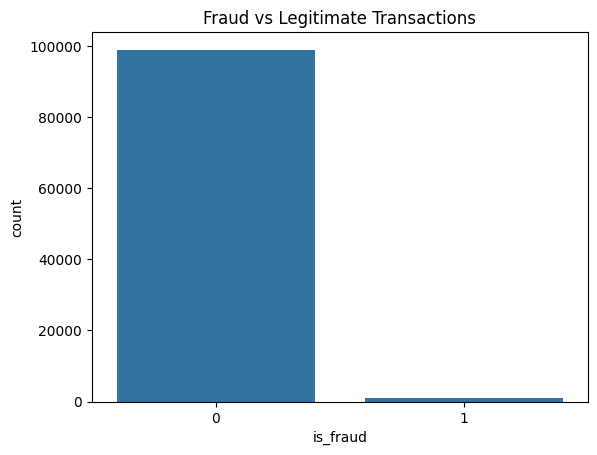

In [8]:
sns.countplot(x='is_fraud', data=train)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

In [9]:
drop_cols = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'city',
    'state',
    'zip',
    'dob',
    'trans_num'
]

train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [10]:
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

In [11]:
train, test = train.align(test, join='left', axis=1, fill_value=0)

In [12]:
X_train = train.drop('is_fraud', axis=1)
y_train = train['is_fraud']

In [13]:
X_test = test.drop('is_fraud', axis=1)
y_test = test['is_fraud']

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [16]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 0.99292


In [17]:
print("\nClassification Report:\n")
print(classification_report(y_test, pred_lr))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24917
           1       0.09      0.13      0.11        83

    accuracy                           0.99     25000
   macro avg       0.55      0.56      0.55     25000
weighted avg       0.99      0.99      0.99     25000



In [18]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred_lr))


Confusion Matrix:

[[24812   105]
 [   72    11]]


In [19]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [20]:
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))

Decision Tree Accuracy: 0.93832


In [21]:
print("\nClassification Report:\n")
print(classification_report(y_test, pred_dt))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     24917
           1       0.03      0.63      0.06        83

    accuracy                           0.94     25000
   macro avg       0.52      0.78      0.52     25000
weighted avg       1.00      0.94      0.97     25000



In [22]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred_dt))


Confusion Matrix:

[[23406  1511]
 [   31    52]]


In [23]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [24]:
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [25]:
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.99768


In [26]:
print("\nClassification Report:\n")
print(classification_report(y_test, pred_rf))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24917
           1       0.80      0.40      0.53        83

    accuracy                           1.00     25000
   macro avg       0.90      0.70      0.77     25000
weighted avg       1.00      1.00      1.00     25000



In [27]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred_rf))


Confusion Matrix:

[[24909     8]
 [   50    33]]


In [28]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.99292
1,Decision Tree,0.93832
2,Random Forest,0.99768


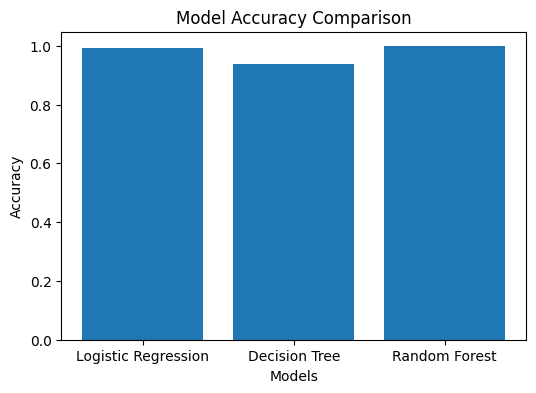

In [29]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()